# ALeRCE — Stamps for OID `313853517426065465`

Uses the **ALeRCE Python client** multisurvey stamps API to fetch science, template, and difference
stamps for a given LSST diaObject and saves them as FITS files in this directory.

Reference: https://alerce.readthedocs.io/en/latest/tutorials/multisurvey_stamps_api.html

Based on patterns from: https://github.com/alercebroker/usecases/blob/master/notebooks/LSST/ALeRCE_LSST_Client_Queries.ipynb

## 1. Imports

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.visualization import ZScaleInterval
from astropy.wcs import WCS

from alerce.core import Alerce

## 2. Connect to the ALeRCE client

In [2]:
# Default constructor works for both ZTF and LSST multisurvey queries
alerce_client = Alerce()
print("ALeRCE client ready.")

ALeRCE client ready.


## 3. Target object

In [3]:
OID = 313853517426065465    # LSST diaObjectId (integer)
OUT_DIR = Path(".")         # save FITS files alongside this notebook

print(f"OID        : {OID}")
print(f"Output dir : {OUT_DIR.resolve()}")

OID        : 313853517426065465
Output dir : /home/jupyter/workspace/tutorials/rubin


## 4. Query detections and identify stamp-bearing epochs

Not every detection stored by ALeRCE triggered a Rubin alert — only those with `has_stamp = True`
carry image cutouts. We filter to those rows before requesting stamps.

For LSST the per-epoch identifier is `measurement_id` (= `diaSourceId`), not `candid`.

In [4]:
df_dets = alerce_client.query_detections(OID, survey="lsst", format="pandas")

print(f"Total detections : {len(df_dets)}")
print(f"Columns          : {list(df_dets.columns)}")
df_dets.head(3)

Total detections : 1131
Columns          : ['band', 'mjd', 'survey_id', 'ra', 'dec', 'oid', 'measurement_id', 'parentDiaSourceId', 'diaObjectId', 'psfFlux', 'psfFluxErr', 'psfFlux_flag', 'psfFlux_flag_edge', 'psfFlux_flag_noGoodPixels', 'scienceFlux', 'scienceFluxErr', 'has_stamp', 'visit', 'detector', 'ssObjectId', 'raErr', 'decErr', 'ra_dec_Cov', 'x', 'xErr', 'y', 'yErr', 'centroid_flag', 'apFlux', 'apFluxErr', 'apFlux_flag', 'apFlux_flag_apertureTruncated', 'isNegative', 'snr', 'psfLnL', 'psfChi2', 'psfNdata', 'trailFlux', 'trailFluxErr', 'trailRa', 'trailRaErr', 'trailDec', 'trailDecErr', 'trailLength', 'trailLengthErr', 'trailAngle', 'trailAngleErr', 'trailChi2', 'trailNdata', 'trail_flag_edge', 'dipoleMeanFlux', 'dipoleMeanFluxErr', 'dipoleFluxDiff', 'dipoleFluxDiffErr', 'dipoleLength', 'dipoleAngle', 'dipoleChi2', 'dipoleNdata', 'forced_PsfFlux_flag', 'forced_PsfFlux_flag_edge', 'forced_PsfFlux_flag_noGoodPixels', 'templateFlux', 'templateFluxErr', 'ixx', 'iyy', 'ixy', 'ixxPSF',

,band,mjd,survey_id,ra,dec,oid,measurement_id,parentDiaSourceId,diaObjectId,psfFlux,...,pixelFlags_suspect,pixelFlags_suspectCenter,pixelFlags_streak,pixelFlags_streakCenter,pixelFlags_injected,pixelFlags_injectedCenter,pixelFlags_injected_template,pixelFlags_injected_templateCenter,glint_trail,band_name
0,2,61088.211979,lsst,150.490734,2.775450,313853517426065465,170019716326752312,0,313853517426065465,5346.0600,...,False,False,False,False,False,False,False,False,False,r
1,2,61088.212444,lsst,150.490754,2.775457,313853517426065465,170019716459921433,0,313853517426065465,5698.3936,...,False,False,False,False,False,False,False,False,False,r
2,4,61088.214331,lsst,150.490731,2.775457,313853517426065465,170019716594663425,0,313853517426065465,6154.0117,...,False,False,False,False,False,False,False,False,False,z


In [5]:
# Only detections that triggered an alert carry stamps
df_stamped = df_dets[df_dets["has_stamp"] == True].sort_values("mjd").copy()

print(f"Detections with stamps : {len(df_stamped)}")
df_stamped[["measurement_id", "band_name", "mjd", "psfFlux", "psfFluxErr"]].head()

Detections with stamps : 1010


,measurement_id,band_name,mjd,psfFlux,psfFluxErr
991,313853517426065465,i,61024.245933,3715.8723,371.60650
992,313853517559234619,i,61024.246431,3474.9246,362.94952
993,313853517693976593,i,61024.246932,3340.8037,360.51367
994,313853517965033565,i,61024.247937,4367.2935,376.61790
995,313853532999516243,i,61024.320330,3837.1200,320.76390


## 5. Fetch stamps via `get_stamps()`

`alerce_client.get_stamps(survey, oid, candid)` returns a dict with three keys:

| Key | Contents |
|---|---|
| `cutoutScience` | Direct-image cutout (HDU with `.data` + `.header`) |
| `cutoutTemplate` | Deep-coadd reference cutout |
| `cutoutDifference` | Difference (science − template) |

For LSST each cutout may also carry **variance** and **mask** planes — the `cutout*` value
is then a list `[flux_hdu, variance_hdu, mask_hdu]`. We handle both cases below.

Here we fetch stamps for the **first three alert-bearing detections**.

In [6]:
STAMP_TYPES = ["Science", "Template", "Difference"]   # capitalised to match client keys
N_FETCH = 3                                            # change to len(df_stamped) for all

stamp_rows = []   # list of dicts: {measurement_id, band, mjd, Science_hdu, Template_hdu, ...}

for _, row in df_stamped.head(N_FETCH).iterrows():
    mid = int(row["measurement_id"])
    print(f"  Fetching measurement_id={mid}  band={row['band_name']}  mjd={row['mjd']:.4f} ...", end=" ")

    try:
        stamps = alerce_client.get_stamps(
            survey="lsst",
            oid=OID,
            candid=mid,           # the parameter name is 'candid' even for LSST
        )
        print("ok")
        entry = {
            "measurement_id": mid,
            "band":           row["band_name"],
            "mjd":            row["mjd"],
        }
        for stype in STAMP_TYPES:
            raw = stamps.get(f"cutout{stype}")
            # When multiple planes are present, take the flux plane (index 0)
            entry[stype] = raw[0] if isinstance(raw, list) else raw
        stamp_rows.append(entry)
    except Exception as exc:
        print(f"FAILED — {exc}")

print(f"\nSuccessfully fetched stamps for {len(stamp_rows)}/{N_FETCH} detections.")

  Fetching measurement_id=313853517426065465  band=i  mjd=61024.2459 ... ok
  Fetching measurement_id=313853517559234619  band=i  mjd=61024.2464 ... ok
  Fetching measurement_id=313853517693976593  band=i  mjd=61024.2469 ... ok

Successfully fetched stamps for 3/3 detections.


## 6. Save as FITS files in this directory

Each cutout HDU has `.data` (numpy float32 array, units nJy) and `.header` (with WCS).
We wrap it in a `PrimaryHDU` and write one file per cutout type per detection.

In [7]:
saved_files = []   # (measurement_id, stype, Path)

for entry in stamp_rows:
    mid = entry["measurement_id"]
    print(f"\nmeasurement_id={mid}  band={entry['band']}  mjd={entry['mjd']:.4f}")

    for stype in STAMP_TYPES:
        hdu = entry.get(stype)
        if hdu is None:
            print(f"  ✗  {stype:12s} — not available")
            continue

        fname = OUT_DIR / f"{OID}_{mid}_{stype.lower()}.fits"
        primary = fits.PrimaryHDU(data=hdu.data, header=hdu.header)
        fits.HDUList([primary]).writeto(fname, overwrite=True)

        size_kb = fname.stat().st_size / 1024
        shape   = hdu.data.shape if hdu.data is not None else "?"
        print(f"  ✓  {stype:12s} → {fname.name}  shape={shape}  ({size_kb:.1f} kB)")
        saved_files.append((mid, stype, fname))

print(f"\nTotal FITS files written: {len(saved_files)}")


measurement_id=313853517426065465  band=i  mjd=61024.2459
  ✓  Science      → 313853517426065465_313853517426065465_science.fits  shape=(30, 30)  (8.4 kB)
  ✓  Template     → 313853517426065465_313853517426065465_template.fits  shape=(30, 30)  (8.4 kB)
  ✓  Difference   → 313853517426065465_313853517426065465_difference.fits  shape=(30, 30)  (8.4 kB)

measurement_id=313853517559234619  band=i  mjd=61024.2464
  ✓  Science      → 313853517426065465_313853517559234619_science.fits  shape=(30, 30)  (8.4 kB)
  ✓  Template     → 313853517426065465_313853517559234619_template.fits  shape=(30, 30)  (8.4 kB)
  ✓  Difference   → 313853517426065465_313853517559234619_difference.fits  shape=(30, 30)  (8.4 kB)

measurement_id=313853517693976593  band=i  mjd=61024.2469
  ✓  Science      → 313853517426065465_313853517693976593_science.fits  shape=(30, 30)  (8.4 kB)
  ✓  Template     → 313853517426065465_313853517693976593_template.fits  shape=(30, 30)  (8.4 kB)
  ✓  Difference   → 313853517426065465

## 7. Inspect FITS headers

The stamps include full WCS — `CRVAL1/2` give the sky position of the reference pixel
and `BUNIT = 'nJy'` confirms the flux units.

In [8]:
# Show header of the first Science stamp
first_science = next((f for mid, st, f in saved_files if st == "Science"), None)

if first_science:
    with fits.open(first_science) as hdul:
        print(hdul.info())
        print()
        print(repr(hdul[0].header))
else:
    print("No Science stamp saved.")

Filename: 313853517426065465_313853517426065465_science.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      22   (30, 30)   float32   
None

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -32 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                   30                                                  
NAXIS2  =                   30                                                  
CUTMINX =                 2982                                                  
CUTMINY =                 2357                                                  
ROTPA   =     184.993034828952 / Pos angle in deg of focal plane +Y wrt North   
BUNIT   = 'nJy     '                                                            
WCSAXES =                    2 / Number of coordinate axes                    

## 8. Display stamps for each fetched detection

Science and template use ZScale; difference uses a symmetric stretch. WCS axes are drawn
using the header stored in each FITS file.

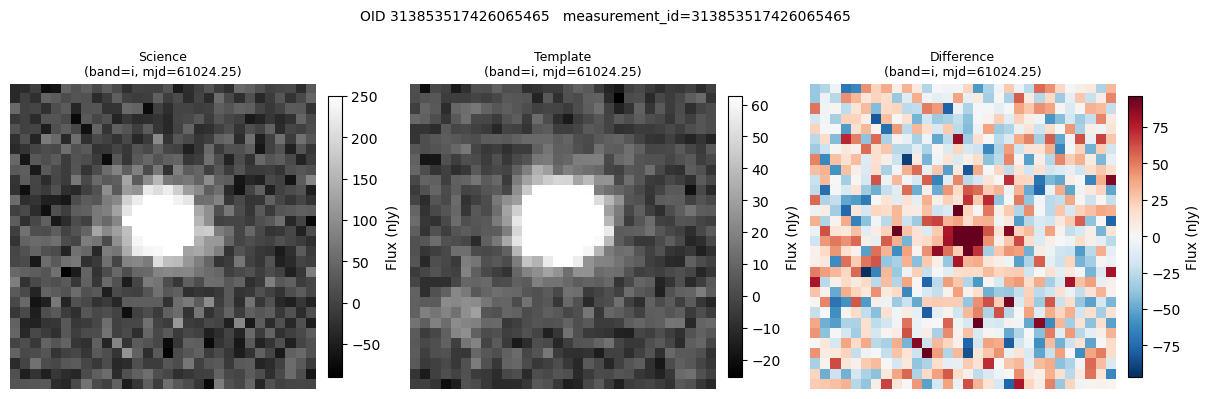

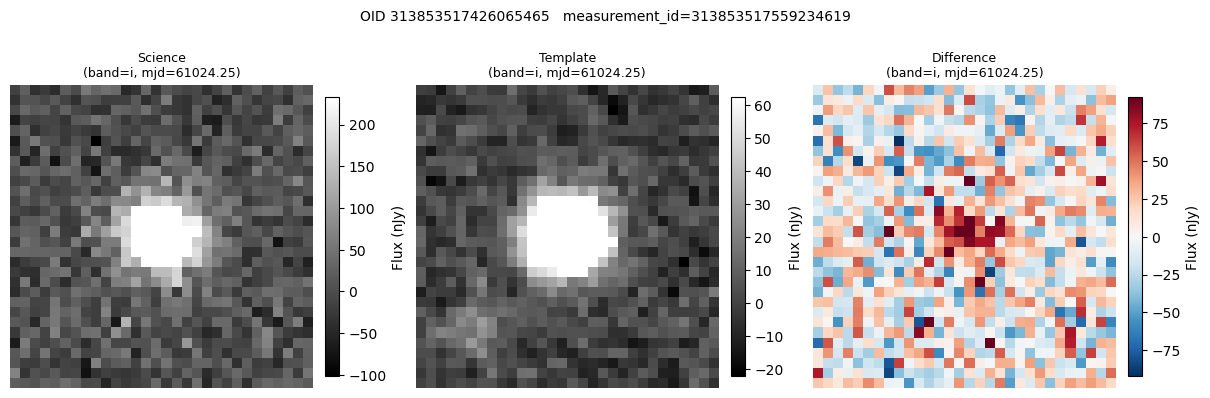

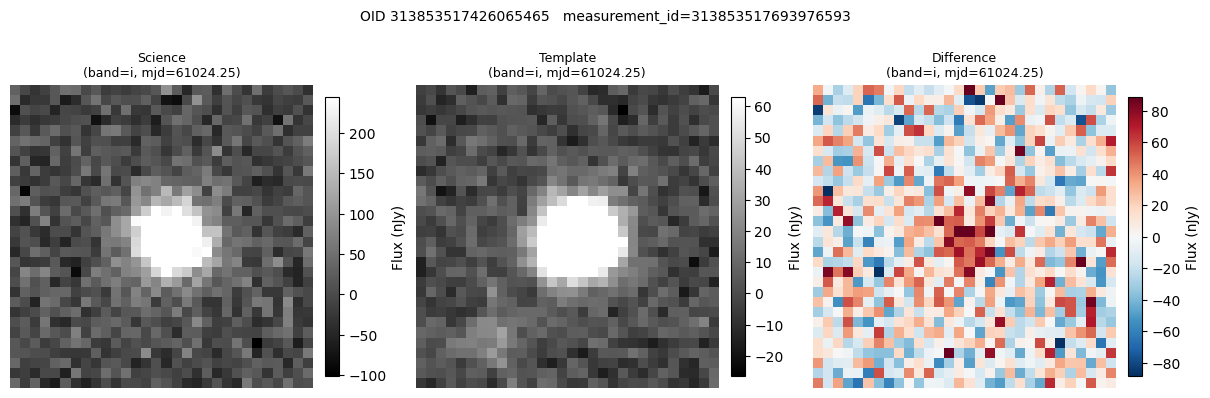

In [9]:
CMAPS = {"Science": "gray", "Template": "gray", "Difference": "RdBu_r"}


def scale(arr, stype):
    arr = np.nan_to_num(arr)
    if stype == "Difference":
        absmax = np.nanpercentile(np.abs(arr), 99)
        return -absmax, absmax
    vmin, vmax = ZScaleInterval(contrast=0.25).get_limits(arr)
    return vmin, vmax


for entry in stamp_rows:
    mid = entry["measurement_id"]
    n = sum(1 for st in STAMP_TYPES if entry.get(st) is not None)
    if n == 0:
        continue

    fig, axes = plt.subplots(
        1, n, figsize=(4 * n, 4.4),
        subplot_kw={"projection": None},    # replaced per-axis below
        constrained_layout=True
    )
    if n == 1:
        axes = [axes]

    ax_idx = 0
    for stype in STAMP_TYPES:
        hdu = entry.get(stype)
        if hdu is None:
            continue

        arr = np.array(hdu.data, dtype=float)
        vmin, vmax = scale(arr, stype)
        ax = axes[ax_idx]
        im = ax.imshow(arr, origin="lower", cmap=CMAPS[stype], vmin=vmin, vmax=vmax)
        ax.set_title(f"{stype}\n(band={entry['band']}, mjd={entry['mjd']:.2f})", fontsize=9)
        ax.axis("off")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Flux (nJy)")
        ax_idx += 1

    fig.suptitle(f"OID {OID}   measurement_id={mid}", fontsize=10)
    plt.show()

## 9. List all FITS files written

In [10]:
fits_files = sorted(OUT_DIR.glob(f"{OID}_*.fits"))
print(f"{len(fits_files)} FITS files for OID {OID}:\n")
for f in fits_files:
    print(f"  {f.name}  ({f.stat().st_size / 1024:.1f} kB)")

9 FITS files for OID 313853517426065465:

  313853517426065465_313853517426065465_difference.fits  (8.4 kB)
  313853517426065465_313853517426065465_science.fits  (8.4 kB)
  313853517426065465_313853517426065465_template.fits  (8.4 kB)
  313853517426065465_313853517559234619_difference.fits  (8.4 kB)
  313853517426065465_313853517559234619_science.fits  (8.4 kB)
  313853517426065465_313853517559234619_template.fits  (8.4 kB)
  313853517426065465_313853517693976593_difference.fits  (8.4 kB)
  313853517426065465_313853517693976593_science.fits  (8.4 kB)
  313853517426065465_313853517693976593_template.fits  (8.4 kB)
